First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Dataset shape: (303, 14)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
c

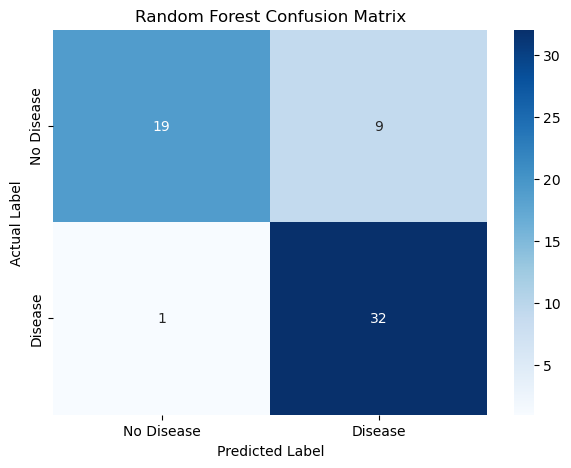


Feature Importance:


,Feature,Importance
2,cp,0.157392
7,thalach,0.117491
9,oldpeak,0.113399
12,thal,0.107062
4,chol,0.087131
11,ca,0.086078
0,age,0.077759
3,trestbps,0.074127
10,slope,0.059454
8,exang,0.057655


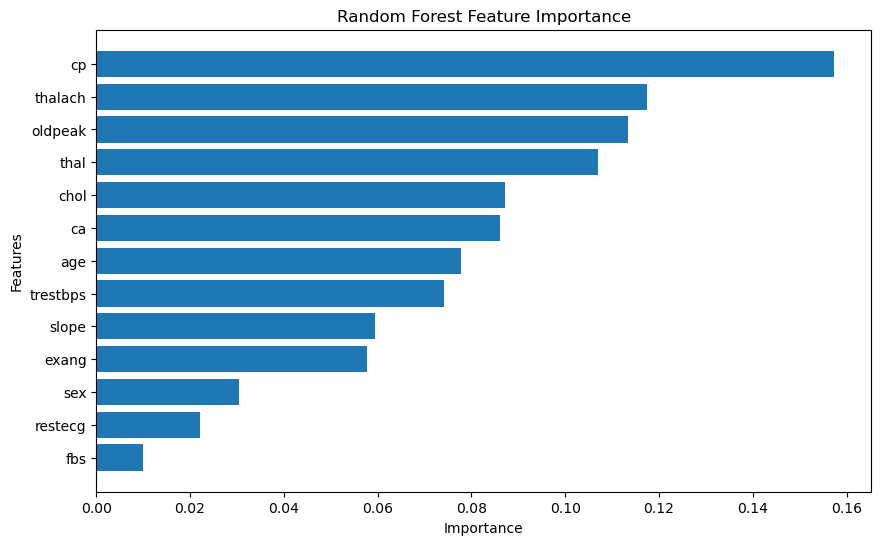

In [1]:

# HEART DISEASE PREDICTION USING RANDOM FOREST


# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 2. Load the dataset
data = pd.read_csv("heart.csv")

# 3. Display first 5 rows
print("First 5 rows:")
display(data.head())

# 4. Display dataset information
print("Dataset shape:", data.shape)
print("\nDataset information:")
data.info()

# 5. Check for missing values
print("\nMissing values:")
print(data.isnull().sum())

# ============================================
# DATA PREPARATION
# ============================================

# 6. Separate features and target
X = data.drop("target", axis=1)
y = data["target"]

print("\nFeatures:")
print(X.columns)

print("\nTarget:")
print(y.name)

# 7. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

# ============================================
# RANDOM FOREST MODEL
# ============================================

# 8. Create Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 9. Train the model
rf_model.fit(X_train, y_train)

print("\nRandom Forest model trained successfully!")

# ============================================
# PREDICTION
# ============================================

# 10. Make predictions
y_pred = rf_model.predict(X_test)

# 11. Display predictions
print("\nPredictions:")
print(y_pred)

# ============================================
# MODEL EVALUATION
# ============================================

# 12. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nRandom Forest Accuracy:")
print(f"{accuracy * 100:.2f}%")

# 13. Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# CONFUSION MATRIX


# 14. Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# 15. Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()


# FEATURE IMPORTANCE


# 16. Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
display(feature_importance)

# 17. Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()